In [1]:
import duckdb
from understatapi import UnderstatClient
from matplotlib import pyplot as plt
import pandas as pd

In [ ]:
# Example: liverpool current player valuations over time

q = """
SELECT P.player_id, P.name, V.date, V.market_value_in_eur
FROM read_csv_auto('https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data/players.csv.gz') P
JOIN read_csv_auto('https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data/player_valuations.csv.gz') V ON P.player_id = V.player_id
WHERE current_club_domestic_competition_id = 'GB1' AND last_season = 2025
AND P.current_club_id = 31
ORDER BY P.player_id, V.date
"""

duckdb.sql(q).show()

┌───────────┬─────────────────┬────────────┬─────────────────────┐
│ player_id │      name       │    date    │ market_value_in_eur │
│   int64   │     varchar     │    date    │        int64        │
├───────────┼─────────────────┼────────────┼─────────────────────┤
│    139208 │ Virgil van Dijk │ 2011-03-05 │               50000 │
│    139208 │ Virgil van Dijk │ 2012-10-01 │             1250000 │
│    139208 │ Virgil van Dijk │ 2013-12-06 │             3000000 │
│    139208 │ Virgil van Dijk │ 2014-07-10 │             5000000 │
│    139208 │ Virgil van Dijk │ 2016-01-08 │            12000000 │
│    139208 │ Virgil van Dijk │ 2016-09-02 │            12000000 │
│    139208 │ Virgil van Dijk │ 2018-02-01 │            50000000 │
│    139208 │ Virgil van Dijk │ 2019-10-12 │           100000000 │
│    139208 │ Virgil van Dijk │ 2019-12-09 │           100000000 │
│    139208 │ Virgil van Dijk │ 2020-08-04 │            80000000 │
│       ·   │      ·          │     ·      │                · 

In [34]:
q = """
SELECT *
FROM read_csv_auto('https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data/appearances.csv.gz') A
LIMIT 10
"""

duckdb.sql(q).show()

┌────────────────┬─────────┬───────────┬────────────────┬────────────────────────┬────────────┬──────────────────┬────────────────┬──────────────┬───────────┬───────┬─────────┬────────────────┐
│ appearance_id  │ game_id │ player_id │ player_club_id │ player_current_club_id │    date    │   player_name    │ competition_id │ yellow_cards │ red_cards │ goals │ assists │ minutes_played │
│    varchar     │  int64  │   int64   │     int64      │         int64          │    date    │     varchar      │    varchar     │    int64     │   int64   │ int64 │  int64  │     int64      │
├────────────────┼─────────┼───────────┼────────────────┼────────────────────────┼────────────┼──────────────────┼────────────────┼──────────────┼───────────┼───────┼─────────┼────────────────┤
│ 2231978_38004  │ 2231978 │     38004 │            853 │                    235 │ 2012-07-03 │ Aurélien Joachim │ CLQ            │            0 │         0 │     2 │       0 │             90 │
│ 2233748_79232  │ 2233748 │  

In [3]:
# Issues with getting FBRef data without avoiding 403 errors so we use understat here
understat = UnderstatClient()

# Get all player data for a league/season
epl_players = understat.league(league="EPL").get_player_data(season="2025")

In [34]:
player_df = pd.DataFrame(epl_players)

In [36]:
player_df["position"].unique()

array(['F S', 'F M', 'F M S', 'M S', 'F', 'M', 'D M S', 'D S', 'D M', 'D',
       'D F M S', 'S', 'GK', 'GK S'], dtype=object)

In [ ]:
'D F M S'.split(" ")

['D', 'F', 'M', 'S']

In [4]:
epl_players[:3]

[{'id': '8260',
  'player_name': 'Erling Haaland',
  'games': '27',
  'time': '2259',
  'goals': '22',
  'xG': '22.47195105999708',
  'assists': '7',
  'xA': '4.683228434994817',
  'shots': '96',
  'key_passes': '20',
  'yellow_cards': '1',
  'red_cards': '0',
  'position': 'F S',
  'team_title': 'Manchester City',
  'npg': '19',
  'npxG': '19.427275620400906',
  'xGChain': '24.82650714367628',
  'xGBuildup': '3.465328110381961'},
 {'id': '13222',
  'player_name': 'Thiago',
  'games': '27',
  'time': '2302',
  'goals': '17',
  'xG': '18.74260649085045',
  'assists': '1',
  'xA': '2.971277406439185',
  'shots': '63',
  'key_passes': '15',
  'yellow_cards': '5',
  'red_cards': '0',
  'position': 'F S',
  'team_title': 'Brentford',
  'npg': '11',
  'npxG': '13.414424546062946',
  'xGChain': '16.38330163434148',
  'xGBuildup': '2.8900308422744274'},
 {'id': '11363',
  'player_name': 'Antoine Semenyo',
  'games': '26',
  'time': '2340',
  'goals': '13',
  'xG': '9.839814426377416',
  'assis

In [5]:
# Find player info
list(filter(lambda p: p['player_name'] == 'Mohamed Salah', epl_players))

[{'id': '1250',
  'player_name': 'Mohamed Salah',
  'games': '19',
  'time': '1626',
  'goals': '4',
  'xG': '6.514106601476669',
  'assists': '6',
  'xA': '5.435673952102661',
  'shots': '48',
  'key_passes': '42',
  'yellow_cards': '1',
  'red_cards': '0',
  'position': 'F M S',
  'team_title': 'Liverpool',
  'npg': '3',
  'npxG': '5.752937763929367',
  'xGChain': '11.591482192277908',
  'xGBuildup': '3.587615504860878'}]

In [7]:
# Get all player matches
player_matches = understat.player(player='1250').get_match_data()

In [22]:
# Convert to dataframe
player_matches_df = pd.DataFrame(player_matches)

# Sort by date
player_matches_df = player_matches_df.sort_values(by="date")

player_matches_df.head()

,goals,shots,xG,time,position,h_team,a_team,h_goals,a_goals,date,id,season,roster_id,xA,assists,key_passes,npg,npxG,xGChain,xGBuildup
390,0,1,0.0623646005988121,6,Sub,Chelsea,Swansea,4,2,2014-09-13,4720,2014,17895,0,0,0,0,0.0623646005988121,0.0623646005988121,0
389,0,0,0,2,Sub,Crystal Palace,Chelsea,1,2,2014-10-18,4702,2014,18957,0,0,0,0,0,0,0
388,0,1,0.4399380087852478,15,Sub,Tottenham,Chelsea,5,3,2015-01-01,4560,2014,22951,0.02637450024485588,0,1,0,0.4399380087852478,0.48311999440193176,0.016807500272989273
387,0,1,0.09675999730825424,24,Sub,Fiorentina,Atalanta,3,2,2015-02-08,4929,2014,52354,0.27118098735809326,0,3,0,0.09675999730825424,0.2731809914112091,0.09675999730825424
386,1,3,0.4587180018424988,82,FWL,Sassuolo,Fiorentina,1,3,2015-02-14,4937,2014,52698,0.22391299903392792,1,2,1,0.4587180018424988,0.7049940228462219,0.02236259914934635


In [24]:
# Rolling stats over games

stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
rolling_stats = list(map(lambda s: f"rolling_{s}_per_90", stats))

window_size = 10

# Get minute counts first
player_matches_df["rolling_min"] = player_matches_df["time"].rolling(window_size).sum()

# Rolling stats/90 for each
for stat, rolling_stat_name in zip(stats, rolling_stats):

    rolling_stat = player_matches_df[stat].rolling(window_size).sum()

    player_matches_df[rolling_stat_name] = rolling_stat / player_matches_df["rolling_min"] * 90

# Only date plus stats
stats_df = player_matches_df[["date"] + rolling_stats]

# drop nas (first window_size - 1)
stats_df = stats_df.dropna()

stats_df.head(10)

,date,rolling_goals_per_90,rolling_xG_per_90,rolling_assists_per_90,rolling_xA_per_90,rolling_key_passes_per_90,rolling_xGChain_per_90,rolling_xGBuildup_per_90
381,2015-04-04,0.900000,0.482645,0.225000,0.238572,3.600000,0.860927,0.287028
380,2015-04-12,0.743802,0.387283,0.185950,0.197167,2.975207,0.699913,0.237213
379,2015-04-20,0.705882,0.379748,0.176471,0.199638,3.176471,0.688963,0.237643
378,2015-04-26,0.615385,0.298144,0.153846,0.182772,2.769231,0.637955,0.268687
377,2015-04-29,0.560748,0.274130,0.140187,0.128528,2.102804,0.564615,0.236843
376,2015-05-03,0.432000,0.319491,0.000000,0.127123,2.304000,0.675264,0.322662
375,2015-05-10,0.417957,0.404579,0.000000,0.107441,1.950464,0.733238,0.312173
374,2015-05-18,0.398818,0.367431,0.000000,0.109965,1.994092,0.698124,0.321671
373,2015-05-24,0.438312,0.403817,0.146104,0.128450,2.337662,0.776301,0.354974
372,2015-05-31,0.434084,0.389019,0.289389,0.148333,2.604502,0.780908,0.353426


([<matplotlib.axis.XTick at 0x16535ab10>,
 [Text(0.0, 0, '2015-04-04'),
  Text(80.0, 0, '2017-09-23'),
  Text(160.0, 0, '2019-11-30'),
  Text(240.0, 0, '2022-02-10'),
  Text(320.0, 0, '2024-04-24')])

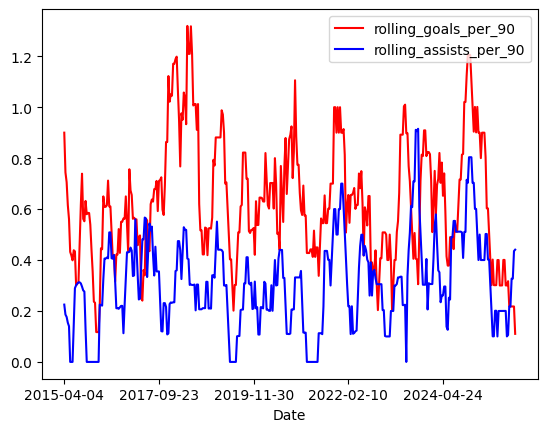

In [25]:
plt.plot(stats_df["date"], stats_df["rolling_goals_per_90"], color="red", label="rolling_goals_per_90")
plt.plot(stats_df["date"], stats_df["rolling_assists_per_90"], color="blue", label="rolling_assists_per_90")
plt.legend()
plt.xlabel("Date")
plt.xticks(stats_df["date"][::80])

In [13]:
# Use helpers

from preprocess import *
understat = UnderstatClient()

In [ ]:
# Look at forwards

f_ids = get_player_ids(understat, {"F"})

['8260', '13222', '11363', '8272', '5555']

In [14]:
# Get each forward's stats df

stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
window_size = 10

for f_id in f_ids[:3]:
    f_stats = get_player_stats_df(understat, f_id, stats, window_size)
    print(f_stats.head())
    

           date  rolling_goals_per_90  rolling_xG_per_90  \
181  2020-05-23              1.304348           0.786954   
180  2020-05-26              0.864198           0.623131   
179  2020-06-13              0.734694           0.479098   
178  2020-06-17              0.481283           0.376565   
177  2020-06-20              0.721925           0.642953   

     rolling_assists_per_90  rolling_xA_per_90  rolling_key_passes_per_90  \
181                0.260870           0.134672                   1.043478   
180                0.246914           0.127467                   0.987654   
179                0.244898           0.126426                   0.979592   
178                0.240642           0.116004                   0.842246   
177                0.240642           0.175442                   0.962567   

     rolling_xGChain_per_90  rolling_xGBuildup_per_90  
181                1.040308                  0.384068  
180                0.860065                  0.360656  
179     